**FOOD SPOILAGE RISK: EDA & Data Leakage-Aware Baseline**

**Target**:The spoilage_risk column(continuous variable) binned into three ordinal classes **Low/Medium/High** using tercile thresholds(multi-class classification).

This notebook confirms the following observations:
- Several columns are **data leakage**(contains commercial-outcome variables) that must be excluded.
- A **leakage-safe baseline** produces a sensible and reasonable model as using leakage features inflates the score. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
RANDOM_STATE = 42

df_perishable= pd.read_csv(r"C:\Users\ngadj\Downloads\ML Project\perishable_cleaned.csv")
df_perishable.head()

,record_id,product_id,product_name,category,store_id,region,supplier_id,transaction_date,expiration_date,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,cost_price,initial_quantity,spoilage_sensitivity,day_of_week,is_weekend,month,daily_demand,demand_variability,temp_abuse_events,distribution_hours,handling_score,packaging_score,spoilage_risk,was_spoiled,quality_grade,days_until_expiry,markdown_applied,discount_pct,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted,risk_class,quality_index,stress_factor,risk_velocity
0,1,BAK_DON_743,Donuts,Bakery,STORE_046,West,SUPPLIER_03,2024-09-25,2024-09-29,4,4,21.0,1.0,2.60,1.22,158,0.50,2,0,9,54,0.35,0,41.5,9,10,0.099,0,A,2,0,0.00,2.60,138,20,12.7,358.80,24.40,166.04,46.3,9,0,low,90,41.50,8.300000
1,2,MEA_SAU_338,Sausages,Meat,STORE_030,Southwest,SUPPLIER_12,2023-04-14,2023-04-21,9,7,0.7,0.3,8.25,4.18,353,0.90,4,0,4,55,0.35,0,38.7,8,8,0.172,0,A,4,0,0.00,8.25,251,102,28.9,2070.75,426.36,595.21,28.7,6,0,medium,64,11.61,4.837500
2,3,BAK_BAG_799,Bagels,Bakery,STORE_035,Midwest,SUPPLIER_08,2024-10-25,2024-10-27,2,2,21.3,1.3,4.12,2.12,483,0.50,4,0,10,331,0.35,0,54.1,4,8,0.201,0,B,0,1,0.69,1.28,483,0,0.0,618.24,0.00,-405.72,-65.6,9,0,medium,32,70.33,18.033333
3,4,PHA_VAC_801,Vaccines,Pharmaceuticals,STORE_003,Midwest,SUPPLIER_11,2023-11-29,2024-02-17,87,80,8.0,3.0,209.56,87.99,477,0.85,2,0,11,7,0.38,0,70.1,5,9,0.230,0,B,79,0,0.00,209.56,477,0,0.0,99960.12,0.00,57988.89,58.0,6,0,high,45,210.30,0.865432
4,5,REA_FRE_422,Fresh Pasta,Ready_to_Eat,STORE_042,West,SUPPLIER_15,2023-08-06,2023-08-09,4,3,3.5,0.5,6.86,3.03,391,0.90,6,1,8,169,0.25,0,64.9,5,6,0.268,0,C,3,1,0.23,5.28,391,0,0.0,2064.48,0.00,879.75,42.6,6,0,high,30,32.45,16.225000


1. **Data quality checks**

In [2]:
print("Rows, Cols:", df_perishable.shape)
print(f"Missing values(total):", int(df_perishable.isna().sum().sum()))
print("Exact duplicate rows:", int(df_perishable.duplicated().sum()))
print(f"Column dtypes:")
df_perishable.dtypes

Rows, Cols: (100000, 46)
Missing values(total): 0
Exact duplicate rows: 0
Column dtypes:


record_id                       int64
product_id                        str
product_name                      str
category                          str
store_id                          str
region                            str
supplier_id                       str
transaction_date                  str
expiration_date                   str
shelf_life_days                 int64
days_remaining_at_purchase      int64
storage_temp                  float64
temp_deviation                float64
base_price                    float64
cost_price                    float64
initial_quantity                int64
spoilage_sensitivity          float64
day_of_week                     int64
is_weekend                      int64
month                           int64
daily_demand                    int64
demand_variability            float64
temp_abuse_events               int64
distribution_hours            float64
handling_score                  int64
packaging_score                 int64
spoilage_ris

In [3]:
# Categorical overview
for c in ["category", "region", "quality_grade"]:
    print(c, "→", df_perishable[c].value_counts().to_dict())

category → {'Pharmaceuticals': 10120, 'Meat': 10055, 'Ready_to_Eat': 10049, 'Bakery': 10039, 'Produce': 10001, 'Deli': 9991, 'Dairy': 9964, 'Seafood': 9957, 'Frozen_Meals': 9923, 'Beverages': 9901}
region → {'Northeast': 29926, 'Southeast': 20104, 'West': 19945, 'Midwest': 15991, 'Southwest': 14034}
quality_grade → {'B': 50037, 'A': 35665, 'C': 14298}


2. **Target: soilage_risk & its binned ordinal classes**

spoilage_risk is a continuous variable(approximately between 0.05-0.47)

In [4]:
print(df_perishable["spoilage_risk"].describe())

# Tercile thresholds
q1,q2= df_perishable["spoilage_risk"].quantile([1/3, 2/3])
print(f"\nTercile thresholds: low <{q1:.3f} <= medium <{q2:.3f} <= high")

df_perishable["risk_class"]= pd.cut(df_perishable["spoilage_risk"],
                                    bins=[-np.inf,q1,q2,np.inf],
                                    labels=["low", "medium", "high"],
                                    )
print("\nClass balance:")
print(df_perishable["risk_class"].value_counts())

count    100000.000000
mean          0.195158
std           0.050558
min           0.053000
25%           0.159000
50%           0.194000
75%           0.229000
max           0.469000
Name: spoilage_risk, dtype: float64

Tercile thresholds: low <0.171 <= medium <0.216 <= high

Class balance:
risk_class
low       33525
medium    33404
high      33071
Name: count, dtype: int64


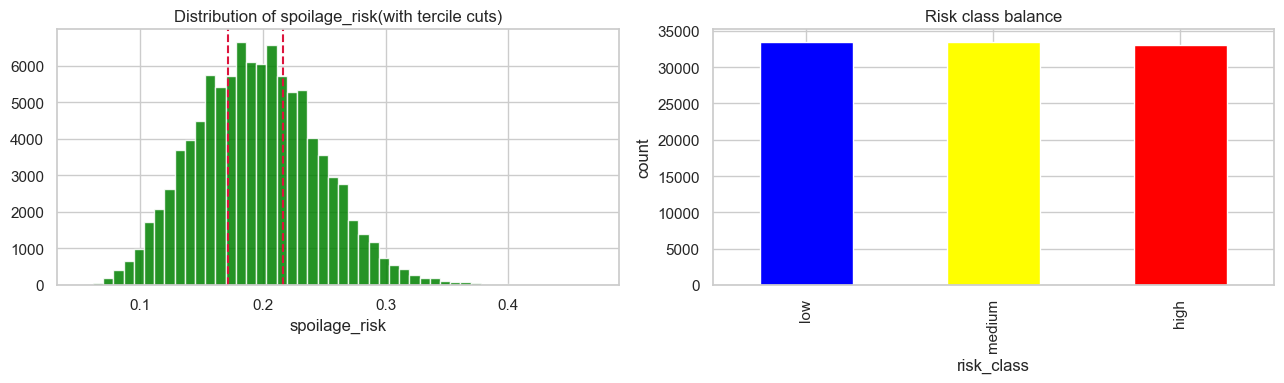

In [5]:
fig, axes= plt.subplots(1,2, figsize=(13,4))
axes[0].hist(df_perishable["spoilage_risk"], bins= 50, color= "green", alpha= 0.85)
for q in (q1, q2):
    axes[0].axvline(q, color="crimson", linestyle="--")
axes[0].set_title("Distribution of spoilage_risk(with tercile cuts)")
axes[0].set_xlabel("spoilage_risk")

order=["low", "medium", "high"]
df_perishable["risk_class"].value_counts()[order].plot(
    kind="bar", ax=axes[1], color=["blue", "yellow", "red"])
axes[1].set_title("Risk class balance")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()

3. **Leakage audit**

The columns were seperated into three groups: **safe predictors, decisions variables**(pricing actions taken in relation to perceived risk) & **outcome/leakage variables**(known after sales). After seperating the variables, we explored correlation with the target variable:spoilage_risk

In [6]:
target="spoilage_risk"

id_cols= ["record_id", "product_id", "product_name", "store_id", 
          "supplier_id", "transaction_date", "expiration_date", "days_until_expiry"]

# leakage realised after outcome: Must not be predictors
leakage_cols=["was_spoiled", "quality_grade", "units_sold", "units_wasted", "waste_pct",
                "waste_cost", "revenue", "profit", "profit_margin_pct"]

# Pricing decisions taken in relation to perceived risk: Should be excluded from the model
decision_cols=["markdown_applied", "discount_pct", "selling_price", "is_promoted"]

# Feature engineering: Creating new interactive features based off safe features

# 1-Quality index: measures the overall care intensity excerted on products from factory to shelf
df_perishable["quality_index"]= df_perishable["packaging_score"] * df_perishable["handling_score"]
# 2-Stress factor: measure the total cumulative thermal abuse products endure during transit
df_perishable["stress_factor"]= df_perishable["temp_deviation"] * df_perishable["distribution_hours"]
# 3-Risk velocity: measures a product's usable life before its arrival in the store
df_perishable["risk_velocity"]= df_perishable["distribution_hours"] / (df_perishable["days_remaining_at_purchase"] + 1)

safe_predictors=[c for c in df_perishable.columns
                 if c not in id_cols + leakage_cols + decision_cols
                 + [target, "risk_class"]
]

print("Safe features (%d):" % len(safe_predictors))
print(safe_predictors)


Safe features (23):
['category', 'region', 'shelf_life_days', 'days_remaining_at_purchase', 'storage_temp', 'temp_deviation', 'base_price', 'cost_price', 'initial_quantity', 'spoilage_sensitivity', 'day_of_week', 'is_weekend', 'month', 'daily_demand', 'demand_variability', 'temp_abuse_events', 'distribution_hours', 'handling_score', 'packaging_score', 'supplier_score', 'quality_index', 'stress_factor', 'risk_velocity']


In [7]:
print([c for c in ["quality_index","stress_factor","risk_velocity"] if c not in df_perishable.columns])

[]


In [8]:
# Correlation of numeric columns with spoilage_risk: illustration of leakage vs signal
target="spoilage_risk"
num=df_perishable.select_dtypes("number")
corr= num.corr(numeric_only=True)[target].drop(target).sort_values(key=np.abs, ascending=False)

def classify_tag(c):
    if c in leakage_cols: return "Leakage"
    if c in decision_cols: return "decision"
    if c in id_cols: return "id"
    else: return "safe"

corr_df_perishable= corr.to_frame("corr_with_risk")
corr_df_perishable["type"]= [classify_tag(c) for c in corr_df_perishable.index]
corr_df_perishable.head(23)

,corr_with_risk,type
quality_index,-0.717132,safe
packaging_score,-0.675422,safe
markdown_applied,0.413035,decision
handling_score,-0.394174,safe
stress_factor,0.390875,safe
discount_pct,0.332430,decision
temp_deviation,0.332139,safe
risk_velocity,0.323373,safe
distribution_hours,0.268697,safe
spoilage_sensitivity,0.253660,safe


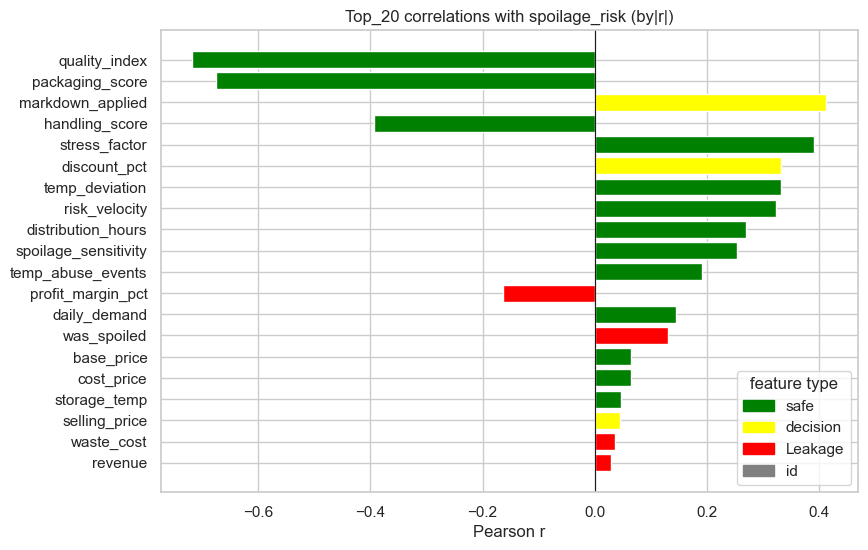

In [9]:
# Visualising the top correlations colored by feature type
top=corr.head(20)
colors={"safe": "green", "decision": "yellow", "Leakage": "red", "id": "gray"}

plt.figure(figsize=(9,6))
plt.barh(top.index[::-1], top.values[::-1],
          color=[colors[classify_tag(c)] for c in top.index[::-1]],
          )
plt.axvline(0, color="k", linewidth= 0.8)
plt.title("Top_20 correlations with spoilage_risk (by|r|)")
plt.xlabel("Pearson r")
handles= [plt.Rectangle((0,0),1,1,color=colors[k]) for k in colors]
plt.legend(handles, colors.keys(), title="feature type", loc="lower right")
plt.tight_layout
plt.show()




The strongest drivers amongst safe predictive features are quality_index(negative), packaging_score (negative), handling score(negative), stress_factor(positive), temp_deviation(positive) and risk_vellocity(positive). Features such as markdown_applied and discount_pct both strongly correlate possitively however, they are decision variables.  

4. **Exploratory Data Analysis(EDA) on safe features**

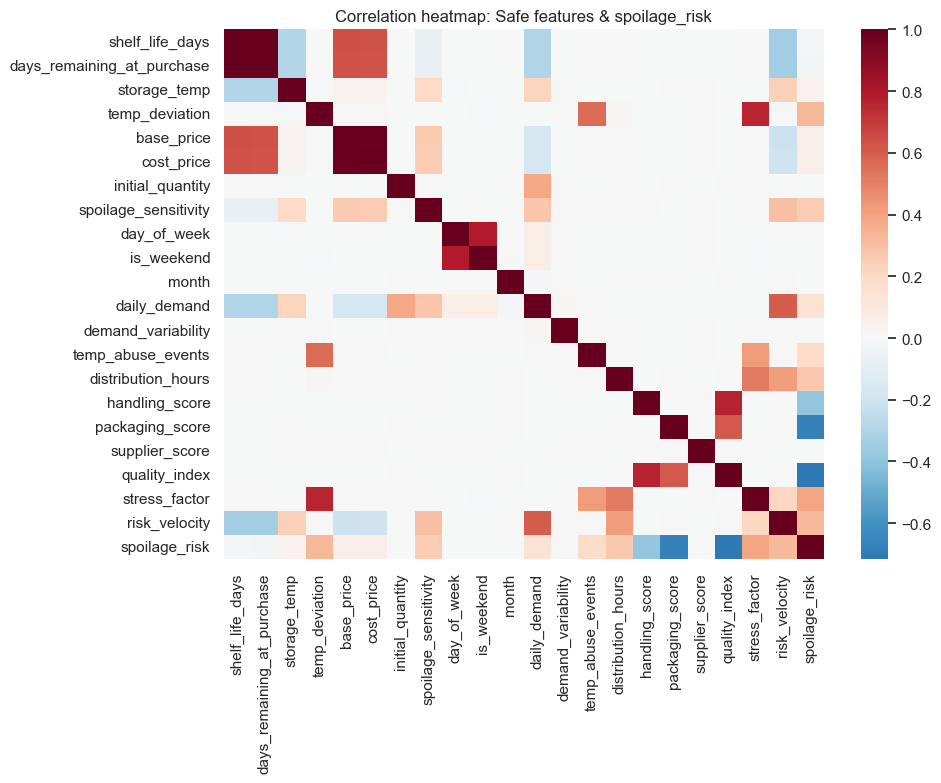

In [10]:
# Correlation heat map between safe numeric features and target
safe_num=df_perishable[safe_predictors].select_dtypes("number").columns.tolist()
plt.figure(figsize=(10,8))
sns.heatmap(df_perishable[safe_num + [target]].corr(numeric_only=True),
            cmap="RdBu_r", center=0, annot=False, square=False)
plt.title("Correlation heatmap: Safe features & spoilage_risk")
plt.tight_layout()
plt.show()



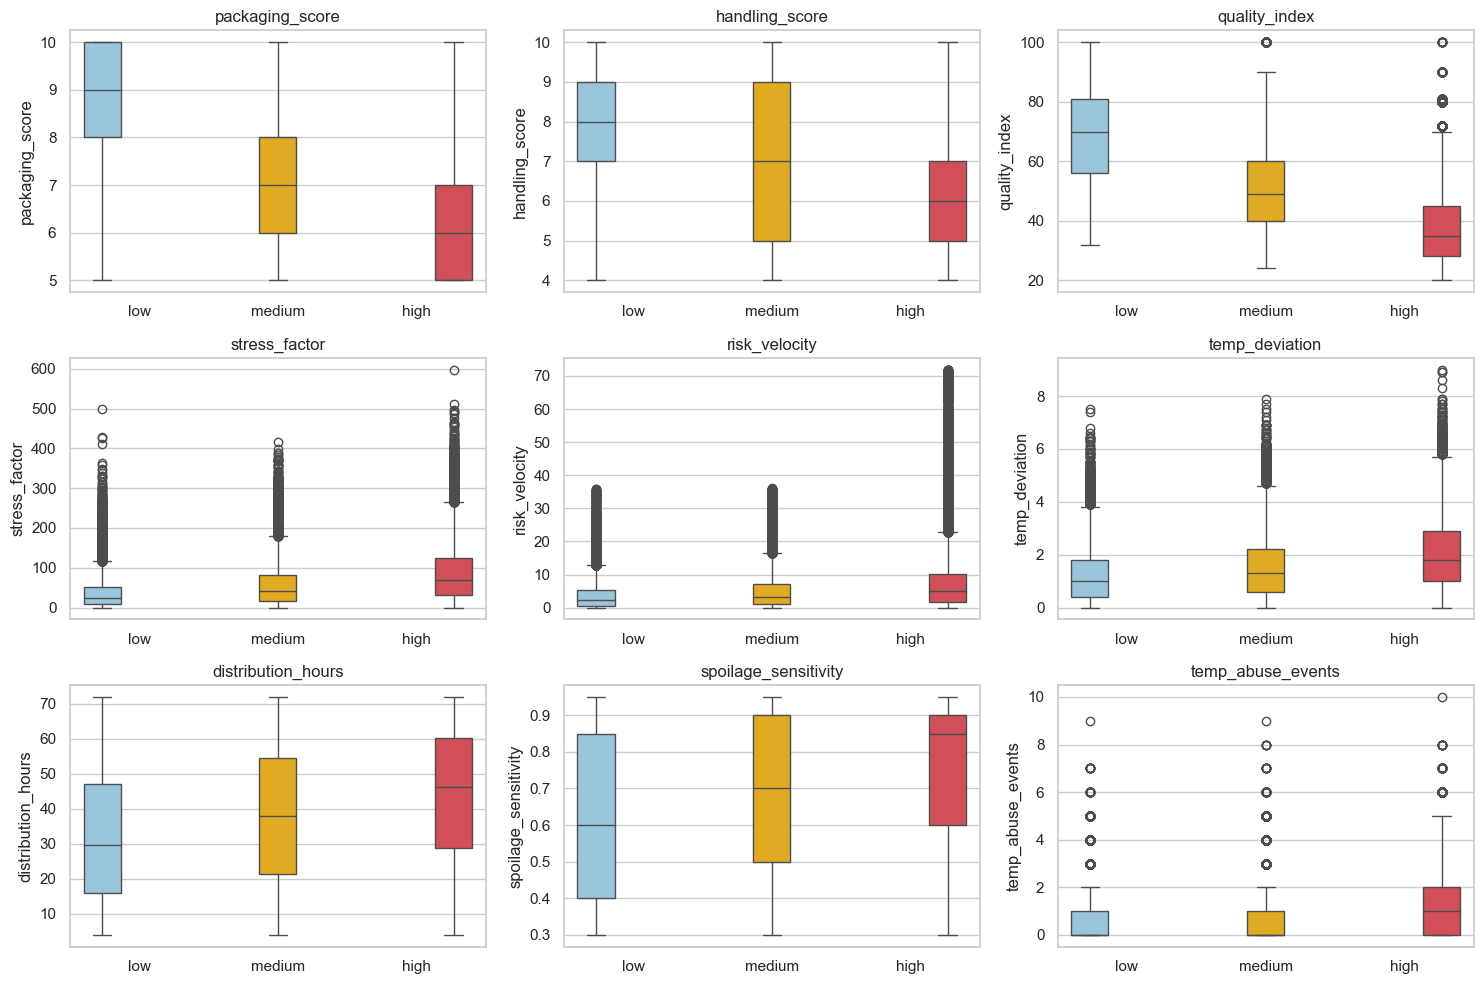

In [11]:
# Boxplots for top drivers by risk class


drivers=["packaging_score", "handling_score", "quality_index", "stress_factor", "risk_velocity", 
        "temp_deviation", "distribution_hours", "spoilage_sensitivity", "temp_abuse_events"]

fig, axes= plt.subplots(3,3, figsize=(15, 10))
order=["low", "medium", "high"]

palette = ["#8ecae6", "#ffb703", "#e63946"]
for ax, col in zip(axes.ravel(), drivers):
    sns.boxplot(data=df_perishable, x="risk_class", 
                y=col, order=order, hue="risk_class",
                palette=palette, legend=False, ax=ax,)
    
    ax.set_title(col); ax.set_xlabel("")
plt.tight_layout()
plt.show()


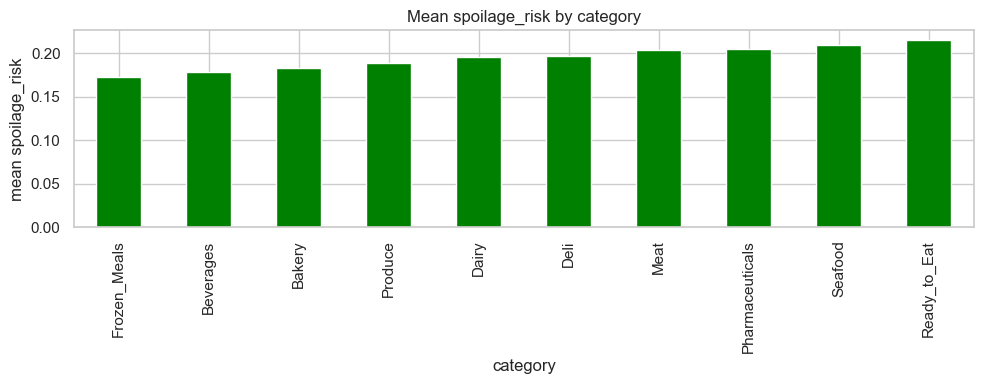

In [12]:
# Mean spoilage_risk by category
plt.figure(figsize=(10,4))
(df_perishable.groupby("category")["spoilage_risk"].mean()
                .sort_values().plot(kind="bar", color="green"))
plt.title("Mean spoilage_risk by category")
plt.ylabel("mean spoilage_risk")
plt.tight_layout()
plt.show()


5. **Leakage-safe baseline models

We build a pipeline(scaling + one-hot encoding on training data only), then we split the data in a stratified way and compare the majority-class baseline against many classifiers.

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

X= df_perishable[safe_predictors].copy()
y= df_perishable["risk_class"].copy()

cat_features= df_perishable[safe_predictors].select_dtypes(exclude="number").columns.tolist()
num_features= df_perishable[safe_predictors].select_dtypes(include="number").columns.tolist()
print("Categorical:", cat_features)
print("Numeric:", len(num_features), "features")

pre= ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),

])

# Stratified train/test
X_train, X_test, y_train, y_test= train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE)

print("train:", X_train.shape, "test:", X_test.shape)



Categorical: ['category', 'region']
Numeric: 21 features
train: (85000, 23) test: (15000, 23)


In [14]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# Model evaluation
models = {
    "Baseline (most_frequent)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
}

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
models["XGBoost"] = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9, eval_metric="mlogloss",
        random_state=RANDOM_STATE, n_jobs=-1)

results=[]

for name, clf in models.items():
    pipe = Pipeline([("pre", pre), ("clf", clf)])
    # XGBoost needs integer-encoded labels
    if clf.__class__.__name__ == "XGBClassifier":
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder().fit(y_train)
        pipe.fit(X_train, le.transform(y_train))
        pred = le.inverse_transform(pipe.predict(X_test))
    else:
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
    })

res = pd.DataFrame(results).sort_values("macro_f1", ascending=False).reset_index(drop=True)
res

,model,accuracy,macro_f1
0,XGBoost,0.941000,0.941152
1,Random Forest,0.856067,0.856588
2,Logistic Regression,0.835200,0.835715
3,Decision Tree,0.802800,0.804247
4,Baseline (most_frequent),0.335267,0.167391


In [16]:
# Report for the best non-baseline model(Random Forest)

best = Pipeline([("pre", pre),
                 ("clf", RandomForestClassifier(
                     n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE))])
best.fit(X_train, y_train)
pred = best.predict(X_test)
print(classification_report(y_test, pred))


              precision    recall  f1-score   support

        high       0.89      0.88      0.89      4961
         low       0.90      0.89      0.89      5029
      medium       0.78      0.80      0.79      5010

    accuracy                           0.86     15000
   macro avg       0.86      0.86      0.86     15000
weighted avg       0.86      0.86      0.86     15000



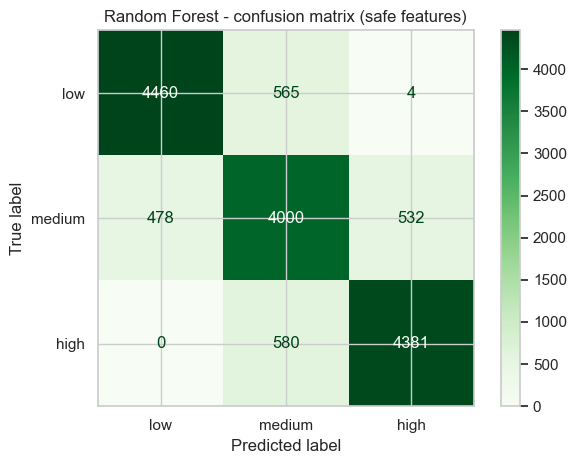

In [17]:
# confusion matrix
cm = confusion_matrix(y_test, pred, labels=["low", "medium", "high"])
ConfusionMatrixDisplay(cm, display_labels=["low", "medium", "high"]).plot(cmap="Greens")
plt.title("Random Forest - confusion matrix (safe features)")
plt.tight_layout(); plt.show() 

**Observation**: The confusion matrix shows how well the Random Forest model's predictions matched with the true risk classes. The diagonal readings indicate the correct predictions and everything else off-diagonal show the error(miscalculations). The medium class has the most confusions and no confusion between the two extremes(hign vs low). 

In [18]:
# Stratify cv macro-F1 of the Random Forest(robustness check)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(best, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
print("CV macro-F1: %.3f +/- %.3f" % (scores.mean(), scores.std()))

CV macro-F1: 0.856 +/- 0.003


6. **Feature Importance (Random Forest)**

In [19]:
# Recovers the expanded features from the fitted ColumnTransformer
ohe= best.named_steps["pre"].named_transformers_["cat"]
# to get the fitted OneHotEncoder from the categorical transformer in the pipeline
feat_names= num_features + list(ohe.get_feature_names_out(cat_features))
# to build a complete list of feature names

importances= pd.Series(
    best.named_steps["clf"].feature_importances_, index= feat_names
).sort_values(ascending=False)
importances_df_perishable = importances.rename_axis("Feature").reset_index(name="Importance")
# extracts the feature_importance_ array from the fitted Random Forest, assign the combined feat_names as index and sort the features in descending order.
importances_df_perishable.head(15)

,Feature,Importance
0,quality_index,0.223466
1,packaging_score,0.172822
2,stress_factor,0.088594
3,handling_score,0.050861
4,distribution_hours,0.050500
5,temp_deviation,0.049178
6,risk_velocity,0.046746
7,days_remaining_at_purchase,0.032351
8,storage_temp,0.031069
9,base_price,0.026328


<Figure size 900x600 with 0 Axes>

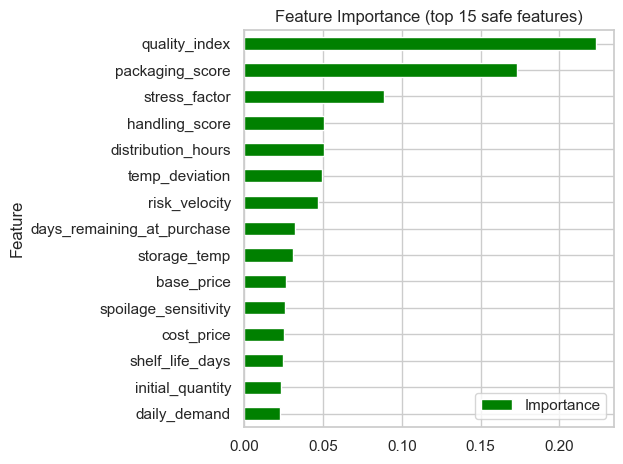

In [20]:
# Feature Importnace plot
plt.figure(figsize=(9,6))
importances_df_perishable.head(15)[::-1].plot(
    x="Feature",
    y= "Importance", kind="barh", color= "green")
plt.title("Feature Importance (top 15 safe features)")
plt.tight_layout(); plt.show()

7. **Model Improvement** (hyper-parameter tunning) 

In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_dist= {
    "clf__n_estimators":[100, 200, 300],
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2"],
    
}

search= RandomizedSearchCV(
    best, param_distributions=param_dist,
    n_iter=20, scoring= "f1_macro", cv=3,
    random_state=RANDOM_STATE, n_jobs=-1
)

search.fit(X_train, y_train)
print(search.best_params_)
print(search.best_score_)

{'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': 30}
0.8498969581195982


**Predicting a new food product**

In [25]:
new_product= pd.DataFrame({
    "category": ["Dairy"],
    "region": ["West"],
    "shelf_life_days": [10],
    "days_remaining_at_purchase": [4],
    "storage_temp": [7.5],
    "temp_deviation": [3.5],
    "base_price": [5.5],
    "cost_price": [2.7],
    "initial_quantity": [300],
    "spoilage_sensitivity": [0.85],
    "day_of_week": [5],
    "is_weekend": [0],
    "month": [7],
    "daily_demand": [95],
    "demand_variability": [0.5],
    "temp_abuse_events": [5],
    "distribution_hours": [60],
    "handling_score": [4],
    "packaging_score": [3],
    "supplier_score": [5],
    
})

new_product= engineer_features(new_product)
new_product

,category,region,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,cost_price,initial_quantity,spoilage_sensitivity,day_of_week,is_weekend,month,daily_demand,demand_variability,temp_abuse_events,distribution_hours,handling_score,packaging_score,supplier_score,quality_index,stress_factor,risk_velocity
0,Dairy,West,10,4,7.5,3.5,5.5,2.7,300,0.85,5,0,7,95,0.5,5,60,4,3,5,12,210.0,12.0


In [26]:
prediction= search.best_estimator_.predict(new_product)
print("Predicted risk class:", prediction[0])

probs= search.best_estimator_.predict_proba(new_product)
probs_dic= {cls: round(float(p), 3) for cls, p in zip(search.best_estimator_.classes_, probs[0])}
print(probs_dic)

Predicted risk class: high
{'high': 0.993, 'low': 0.0, 'medium': 0.007}


7. **Leakage Check**

In this part, we included the outcome/decision columns as predictors to compare the macro-F1 score to the previous model.


In [ ]:
# effect of spoilage_risk target in combination with decision variables and outcome columns
from sklearn.metrics import f1_score
leaky_features= safe_predictors + decision_cols + ["was_spoiled", "waste_pct", "units_wasted", "waste_cost"]
xl= df_perishable[leaky_features].copy()

cat_leaky= df_perishable[leaky_features].select_dtypes(exclude="number").columns.tolist()
num_leaky= df_perishable[leaky_features].select_dtypes(include="number").columns.tolist()
pre_leaky=ColumnTransformer([
    ("num", StandardScaler(), num_leaky),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_leaky),
])
Xl_tr, Xl_te, yl_tr, yl_te= train_test_split(
    xl, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE)
leaky= Pipeline([("pre", pre_leaky),
                 ("clf", RandomForestClassifier(
                     n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE))])
leaky.fit(Xl_tr, yl_tr)
pred_leaky= leaky.predict(Xl_te)

macro_F1_safe= f1_score(y_test, pred, average="macro") 
macro_F1_leaky= f1_score( yl_te, pred_leaky, average="macro")
print("Target= spoilage_risk")
print(f"  Reasonable (safe) macro-F1: {macro_F1_safe:.3f}")
print(f"  Leaky             macro-F1: {macro_F1_leaky:.3f}")
print(f"Small inflation: spoilage_risk is almost independent of the outcome columns")

Target= spoilage_risk
  Reasonable (safe) macro-F1: 0.857
  Leaky             macro-F1: 0.855
Small inflation: spoilage_risk is almost independent of the outcome columns


In [ ]:
# Contrast: using was_spoiled as the target
y_trial= df_perishable["was_spoiled"]
def macro_f1_for(features):
    x_trial= df_perishable[features]
    cat_trial= x_trial.select_dtypes(exclude="number").columns.tolist()
    num_trial= x_trial.select_dtypes(include="number").columns.tolist()
    pre_trial= ColumnTransformer([
        ("num", StandardScaler(), num_trial),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_trial)])
    Xtr,Xte, ytr, yte= train_test_split(
        x_trial, y_trial, test_size=0.15, stratify=y_trial, random_state=RANDOM_STATE)
    trial= Pipeline([("pre", pre_trial),
                     ("clf", RandomForestClassifier(
                         n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE))])
    trial.fit(Xtr, ytr)
    return f1_score(yte, trial.predict(Xte), average="macro")

safe= macro_f1_for(safe_predictors)
leaky= macro_f1_for(safe_predictors + ["units_wasted", "waste_pct", "waste_cost"])
print("Target= was_spoiled(realised outcome)")
print(f"Reasonable (safe) macro_F1: {safe:.3f}")
print(f"leaky             macro_F1: {leaky:.3f}")
print(f"Leakage inflates the score which justifies why leakage audit is important")

    

Target= was_spoiled(realised outcome)
Reasonable (safe) macro_F1: 0.446
leaky             macro_F1: 0.908
Leakage inflates the score which justifies why leakage audit is important
